In [146]:
import numpy as np
from sklearn import datasets
from sklearn.manifold import Isomap
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.linear_model import LogisticRegression
from matplotlib import pyplot as plt


In [147]:
digits = datasets.load_digits() #loading the dataset
print(digits.data.shape)

(1797, 64)


First we wish to reduce the dimensionality of the data, we use an unsupervised ML technique called Isomap: 

In [148]:
dim_red_model = Isomap(n_components=5, eigen_solver='auto') # reducing the dimension to 3
dim_red_model.fit(digits.data) # training the model

/home/gabriele/anaconda3/envs/jupyter_env/lib/python3.11/site-packages/sklearn/manifold/_isomap.py:360: UserWarning: The number of connected components of the neighbors graph is 2 > 1. Completing the graph to fit Isomap might be slow. Increase the number of neighbors to avoid this issue.
  self._fit_transform(X)
/home/gabriele/anaconda3/envs/jupyter_env/lib/python3.11/site-packages/scipy/sparse/_index.py:168: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.
  self._set_intXint(row, col, x.flat[0])


,n_neighbors,5
,radius,None
,n_components,5
,eigen_solver,'auto'
,tol,0
,max_iter,None
,path_method,'auto'
,neighbors_algorithm,'auto'
,n_jobs,None
,metric,'minkowski'
,p,2


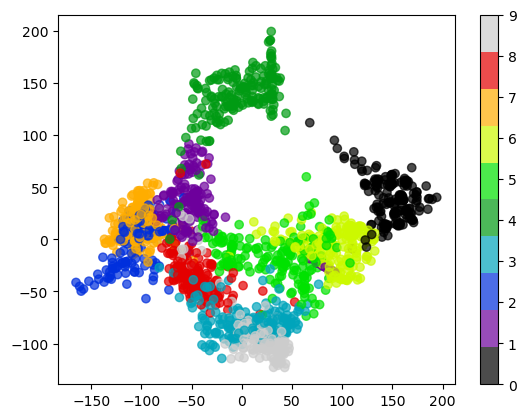

In [155]:
#function for creating a discrete color map
def discrete_cmap(N, base_cmap=None):
    """Create an N-bin discrete colormap from the specified input map"""
    base = plt.colormaps[base_cmap]
    color_list = base(np.linspace(0, 1, N))
    cmap_name = base.name + str(N)
    return base.from_list(cmap_name, color_list, N)

X = dim_red_model.transform(digits.data) 

#making a scatter plot of the data considering two of the fetures
f1 = X[:, 0]
f2 = X[:, 1]
y = digits.target # targets

plt.scatter(f1, f2, c=digits.target, cmap=discrete_cmap(10, 'nipy_spectral'), alpha=0.7)
plt.colorbar(ticks=range(10))

We now employ a supervised classification algorithm (logistic regression)

In [140]:
#splitting the data (after dim reduction) into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.8)

In [141]:
classification = LogisticRegression(solver='sag')
classification.fit(X_train, y_train)

/home/gabriele/anaconda3/envs/jupyter_env/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'sag'
,max_iter,100
,multi_class,'deprecated'


In [142]:
#predicting on the test set
classification.predict(X_test)

array([6, 3, 6, 0, 1, 4, 4, 6, 6, 8, 3, 6, 0, 5, 0, 3, 1, 2, 9, 6, 9, 5,
       3, 7, 6, 9, 5, 1, 5, 5, 4, 7, 9, 2, 1, 1, 0, 1, 4, 0, 3, 6, 9, 1,
       1, 4, 1, 6, 9, 7, 6, 1, 9, 3, 7, 8, 3, 3, 5, 1, 4, 5, 2, 7, 4, 4,
       0, 2, 9, 8, 5, 7, 8, 0, 3, 5, 7, 3, 4, 3, 7, 4, 3, 0, 1, 6, 2, 6,
       7, 6, 6, 9, 8, 0, 1, 6, 8, 3, 7, 6, 3, 7, 9, 8, 0, 7, 4, 3, 2, 7,
       7, 8, 3, 4, 3, 3, 4, 5, 5, 2, 4, 1, 4, 3, 2, 4, 8, 2, 3, 3, 3, 5,
       9, 1, 4, 7, 4, 8, 5, 3, 8, 2, 1, 2, 5, 0, 5, 1, 0, 2, 9, 0, 6, 1,
       9, 6, 6, 8, 3, 0, 7, 2, 8, 5, 9, 8, 1, 3, 3, 2, 0, 5, 9, 6, 9, 3,
       8, 7, 5, 8, 1, 2, 3, 8, 6, 2, 0, 8, 2, 4, 9, 5, 9, 3, 0, 8, 4, 0,
       2, 0, 2, 9, 2, 1, 9, 6, 9, 5, 2, 9, 1, 7, 9, 1, 3, 9, 2, 3, 4, 7,
       4, 5, 1, 3, 8, 2, 2, 4, 4, 0, 7, 9, 8, 8, 0, 4, 5, 4, 0, 7, 4, 3,
       5, 6, 2, 3, 0, 1, 6, 6, 1, 5, 2, 2, 4, 7, 6, 5, 5, 0, 7, 0, 5, 7,
       6, 0, 8, 8, 6, 1, 8, 0, 7, 4, 3, 8, 9, 3, 1, 2, 1, 3, 4, 6, 3, 9,
       5, 0, 3, 4, 8, 1, 0, 9, 1, 4, 9, 4, 5, 9, 1,

In [143]:
#checking the accuracy of the estimator on the train data (!BAD!)
print(accuracy_score(y_train, classification.predict(X_train)))
print(confusion_matrix(y_train, classification.predict(X_train)))

0.9756437021572721
[[146   0   0   0   0   0   0   0   0   0]
 [  0 141   0   0   0   0   0   0   0   0]
 [  0   0 140   0   0   0   0   0   2   0]
 [  0   0   0 136   0   1   0   1   3   1]
 [  0   0   0   0 141   0   0   0   0   1]
 [  0   1   0   0   0 141   1   0   0   2]
 [  0   5   0   0   0   1 138   0   0   0]
 [  0   0   0   0   0   0   0 147   0   1]
 [  0   4   2   2   0   0   0   0 127   3]
 [  0   0   0   1   0   2   0   0   1 145]]


In [ ]:
# for a true assessment of the performance of the estimator we check
# the accuracy and confusion matrix on the the test set 
print(accuracy_score(y_test, classification.predict(X_test)))
print(confusion_matrix(y_test, classification.predict(X_test)))

0.9583333333333334
[[32  0  0  0  0  0  0  0  0  0]
 [ 0 39  1  0  0  0  0  0  1  0]
 [ 0  0 34  0  0  0  0  0  1  0]
 [ 0  0  0 41  0  0  0  0  0  0]
 [ 0  0  0  0 39  0  0  0  0  0]
 [ 0  0  0  0  0 35  1  0  0  1]
 [ 0  3  0  0  0  0 34  0  0  0]
 [ 0  0  0  0  0  0  0 31  0  0]
 [ 0  1  1  1  0  0  0  0 30  3]
 [ 0  0  0  1  0  0  0  0  0 30]]


As expected, the accuracy of the classification is lower on the validation set that on the one used for training the model.

